<a href="https://colab.research.google.com/github/toneyzhen/CMPE-258-Homework2-Object-Detection/blob/main/YOLOv8_COCO_Training_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YOLOv8 Object Detection: Baseline to Improved Training
**Assignment: Option 1 - Training Optimization**

1. Environment setup
2. Dataset preparation (COCO128 + custom annotation via Label Studio)
3. **Baseline**: YOLOv8n pretrained on COCO, no fine-tuning
4. **Improved**: YOLOv8s fine-tuned with enhanced strategy
5. COCO-style evaluation and comparison

> Set runtime to **T4 GPU** before running (Runtime > Change runtime type)

## 1. Environment Setup

In [1]:
!pip install -U torch==2.3.1
!pip install torchvision==0.17.2

  Using cached torch-2.3.1-cp312-cp312-manylinux1_x86_64.whl.metadata (26 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
Using cached torch-2.3.1-cp312-cp312-manylinux1_x86_64.whl (779.1 MB)
Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Attempting uninstall: nvidia-nccl-cu12
    Found existing installation: nvidia-nccl-cu12 2.19.3
    Uninstalling nvidia-nccl-cu12-2.19.3:
      Successfully uninstalled nvidia-nccl-cu12-2.19.3
  Attempting uninstall: torch
    Found existing installation: torch 2.2.2
    Uninstalling torch-2.2.2:
      Successfully uninstalled torch-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.17.2 requires torch==2.2.2, but you have torch 2.3.1 which is incompatible.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.3.

In [2]:
# ── Environment fix: run this cell, then NO restart needed ───────────
import sys, site, pathlib, subprocess

# Write a .pth sitecustomize that patches PIL._Ink on every interpreter start
pth_code = '''
import sys
try:
    import PIL._typing as _pt
    if not hasattr(_pt, '_Ink'):
        _pt._Ink = int
        sys.modules['PIL._typing'] = _pt
    if 'PIL.ImageText' in sys.modules:
        del sys.modules['PIL.ImageText']
except Exception:
    pass
'''

# Install into site-packages so it runs automatically
site_pkgs = site.getsitepackages()[0]
fix_file = pathlib.Path(site_pkgs) / 'pil_ink_fix.pth'
fix_file.write_text(pth_code)
print('Installed pil_ink_fix.pth to:', fix_file)

# Apply immediately in this session too
import PIL._typing as _pt
if not hasattr(_pt, '_Ink'):
    _pt._Ink = int
    sys.modules['PIL._typing'] = _pt
if 'PIL.ImageText' in sys.modules:
    del sys.modules['PIL.ImageText']
print('PIL._Ink patched in current session:', hasattr(_pt, '_Ink'))

# Pin numpy and install ultralytics
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'numpy<2.0', '--upgrade'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'ultralytics==8.3.0', 'pycocotools'], check=True)
print('All done - no restart needed, continue to the next cell.')


Installed pil_ink_fix.pth to: /usr/local/lib/python3.12/dist-packages/pil_ink_fix.pth
PIL._Ink patched in current session: True
All done - no restart needed, continue to the next cell.


> **After the cell above finishes, click Runtime > Restart session.**  
> Then run all remaining cells normally. Do NOT re-run this fix cell after restarting.

## 2. Dataset Preparation

We use **COCO128** - a 128-image subset of COCO 2017 train.

**Custom annotation:** 20 images are extracted for Label Studio annotation and used as the validation split.

In [3]:
# PIL._Ink patch - inject before ultralytics loads
import sys
import PIL._typing as _pt
if not hasattr(_pt, '_Ink'):
    _pt._Ink = int
    sys.modules['PIL._typing'] = _pt
if 'PIL.ImageText' in sys.modules:
    del sys.modules['PIL.ImageText']

from ultralytics import YOLO, settings
from pathlib import Path
import shutil, yaml

_m = YOLO('yolov8n.pt')
_m.val(data='coco128.yaml', imgsz=640, verbose=False, workers=0)

datasets_dir = Path(settings['datasets_dir'])
coco128_dir  = datasets_dir / 'coco128'
img_dir      = coco128_dir / 'images/train2017'
lbl_dir      = coco128_dir / 'labels/train2017'

n_imgs = len(list(img_dir.glob('*.jpg')))
print('COCO128 location:', coco128_dir)
print('Images available:', n_imgs)


Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.2.2+cu121 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 168 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs


val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.03it/s]


                   all        128        929      0.638      0.536      0.607      0.448
Speed: 0.3ms preprocess, 7.4ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to runs/detect/val4
COCO128 location: /content/datasets/coco128
Images available: 128


In [4]:
COCO_CLASSES = [
    'person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
    'traffic light','fire hydrant','stop sign','parking meter','bench','bird','cat',
    'dog','horse','sheep','cow','elephant','bear','zebra','giraffe','backpack',
    'umbrella','handbag','tie','suitcase','frisbee','skis','snowboard','sports ball',
    'kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket',
    'bottle','wine glass','cup','fork','knife','spoon','bowl','banana','apple',
    'sandwich','orange','broccoli','carrot','hot dog','pizza','donut','cake','chair',
    'couch','potted plant','bed','dining table','toilet','tv','laptop','mouse',
    'remote','keyboard','cell phone','microwave','oven','toaster','sink',
    'refrigerator','book','clock','vase','scissors','teddy bear','hair drier','toothbrush'
]
print(len(COCO_CLASSES), 'COCO classes loaded.')


80 COCO classes loaded.


### 2a. Extract Images for Custom Annotation

In [5]:
import random

random.seed(42)
all_images    = list(img_dir.glob('*.jpg'))
custom_images = random.sample(all_images, 20)

custom_dir = Path('/content/custom_split')
for sub in ['images/to_annotate','images/annotated','labels/annotated','original_labels']:
    (custom_dir / sub).mkdir(parents=True, exist_ok=True)

for img in custom_images:
    shutil.copy(img, custom_dir / 'images/to_annotate' / img.name)
    lbl = lbl_dir / (img.stem + '.txt')
    if lbl.exists():
        shutil.copy(lbl, custom_dir / 'original_labels' / lbl.name)

print('Extracted', len(custom_images), 'images to custom_split/images/to_annotate')
print('Download these to your machine and annotate in Label Studio.')


Extracted 20 images to custom_split/images/to_annotate
Download these to your machine and annotate in Label Studio.


### 2b. Label Studio Annotation Instructions

1. Install Label Studio on your local machine:
   ```
   pip install label-studio
   label-studio start
   ```
2. Download the 20 images from `/content/custom_split/images/to_annotate/`.
3. Create a new project with template **Object Detection with Bounding Boxes**.
4. Paste the XML config from the next cell.
5. Import images, draw bounding boxes, then **Export > YOLO format**.
6. Upload labels to `/content/custom_split/labels/annotated/` and images to `/content/custom_split/images/annotated/`.

> **Shortcut**: Set `USE_ORIGINAL_AS_FALLBACK = True` in Section 2c if you want to skip manual annotation and use the original COCO labels.

In [6]:
label_items = ''.join('<Label value="' + c + '"/>\n' for c in COCO_CLASSES)
xml_config = (
    '<View>\n'
    '  <Image name="image" value="$image"/>\n'
    '  <RectangleLabels name="label" toName="image">\n'
    + label_items
    + '  </RectangleLabels>\n'
    + '</View>'
)
with open('/content/label_studio_config.xml', 'w') as f:
    f.write(xml_config)
print('Saved /content/label_studio_config.xml')
print(len(COCO_CLASSES), 'classes included.')


Saved /content/label_studio_config.xml
80 classes included.


### 2c. Merge Annotations and Build Dataset

In [7]:
USE_ORIGINAL_AS_FALLBACK = True  # Set False if you annotated in Label Studio

if USE_ORIGINAL_AS_FALLBACK:
    print('Using original COCO labels as fallback...')
    for img in custom_images:
        shutil.copy(img, custom_dir / 'images/annotated' / img.name)
        lbl = lbl_dir / (img.stem + '.txt')
        if lbl.exists():
            shutil.copy(lbl, custom_dir / 'labels/annotated' / lbl.name)

merged = Path('/content/merged_dataset')
for sub in ['images/train','images/val','labels/train','labels/val']:
    (merged / sub).mkdir(parents=True, exist_ok=True)

for img in all_images:
    if img not in custom_images:
        shutil.copy(img, merged / 'images/train' / img.name)
        lbl = lbl_dir / (img.stem + '.txt')
        if lbl.exists():
            shutil.copy(lbl, merged / 'labels/train' / lbl.name)

for img in (custom_dir / 'images/annotated').glob('*.jpg'):
    shutil.copy(img, merged / 'images/val' / img.name)
for lbl in (custom_dir / 'labels/annotated').glob('*.txt'):
    shutil.copy(lbl, merged / 'labels/val' / lbl.name)

dataset_cfg = {
    'path': str(merged), 'train': 'images/train', 'val': 'images/val',
    'nc': 80, 'names': COCO_CLASSES,
}
with open('/content/merged_dataset.yaml', 'w') as f:
    yaml.dump(dataset_cfg, f)

n_train = len(list((merged / 'images/train').glob('*.jpg')))
n_val   = len(list((merged / 'images/val').glob('*.jpg')))
print('Train:', n_train, 'images')
print('Val  :', n_val,   'images')
print('Saved /content/merged_dataset.yaml')


Using original COCO labels as fallback...
Train: 108 images
Val  : 20 images
Saved /content/merged_dataset.yaml


## 3. Baseline: YOLOv8n (No Fine-tuning)

YOLOv8n with pretrained COCO weights, evaluated on our val split as-is.  
No additional training - this is the out-of-the-box performance.

In [8]:
# PIL._Ink patch - inject before ultralytics loads
import sys
import PIL._typing as _pt
if not hasattr(_pt, '_Ink'):
    _pt._Ink = int
    sys.modules['PIL._typing'] = _pt
if 'PIL.ImageText' in sys.modules:
    del sys.modules['PIL.ImageText']

from ultralytics import YOLO

baseline_model = YOLO('yolov8n.pt')
print('=' * 60)
print('BASELINE: YOLOv8n | Pretrained COCO | No fine-tuning')
print('=' * 60)

baseline_results = baseline_model.val(
    data='/content/merged_dataset.yaml',
    imgsz=640, batch=16, conf=0.001, iou=0.6,
    verbose=True, name='baseline_eval',
)

baseline_map50     = baseline_results.box.map50
baseline_map50_95  = baseline_results.box.map
baseline_precision = baseline_results.box.mp
baseline_recall    = baseline_results.box.mr

print('mAP@0.5      :', round(baseline_map50, 4))
print('mAP@0.5:0.95 :', round(baseline_map50_95, 4))
print('Precision    :', round(baseline_precision, 4))
print('Recall       :', round(baseline_recall, 4))


BASELINE: YOLOv8n | Pretrained COCO | No fine-tuning
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.2.2+cu121 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 168 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs


val: Scanning /content/merged_dataset/labels/val... 20 images, 0 backgrounds, 0 corrupt: 100%|██████████| 20/20 [00:00<00:00, 1746.79it/s]

val: New cache created: /content/merged_dataset/labels/val.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<00:00,  1.66it/s]


                   all         20        161      0.577      0.572      0.619      0.438
                person          9         34      0.613      0.941      0.858      0.583
               bicycle          1          3          1          0     0.0446     0.0383
                   car          3         20      0.695       0.25       0.36      0.225
            motorcycle          1          1      0.245          1      0.995      0.895
              airplane          1          2      0.485          1      0.828      0.745
                 train          1          1      0.353          1      0.995      0.995
                 truck          2          7      0.728      0.429      0.561      0.308
         traffic light          2         12      0.671       0.25      0.257      0.173
                 bench          1          1          1          0          0          0
                   dog          1          1      0.556          1      0.995      0.796
               giraff

## 4. Improved: YOLOv8s - Enhanced Training Strategy

| Change | Baseline | Improved | Rationale |
|--------|----------|----------|-----------|
| Model | YOLOv8n | YOLOv8s | Larger backbone, more capacity |
| Optimizer | SGD | AdamW | Better convergence on small datasets |
| Scheduler | Linear decay | Cosine annealing | Smoother LR, better final weights |
| MixUp | Off | 0.15 | Reduces overfitting via image blending |
| Warmup | 3 epochs | 5 epochs | More stable early training |
| Backbone freeze | None | First 10 layers | Preserves low-level COCO features |

In [9]:
improved_model = YOLO('yolov8s.pt')
print('=' * 60)
print('IMPROVED: YOLOv8s | AdamW + Cosine LR + Augmentation')
print('=' * 60)

improved_model.train(
    data='/content/merged_dataset.yaml',
    epochs=200, imgsz=640, batch=32,
    optimizer='AdamW', lr0=0.0003, lrf=0.01,
    cos_lr=True, warmup_epochs=5,
    mosaic=1.0, mixup=0.2,
    hsv_h=0.1, hsv_s=0.7, hsv_v=0.4,
    fliplr=0.5, flipud=0.01,
    degrees=10, translate=0.1, scale=0.5,
    close_mosaic=15, weight_decay=0.0005,
    patience=20, pretrained=True, freeze=10,
    name='improved_training', verbose=True,
)


100%|██████████| 21.5M/21.5M [00:00<00:00, 44.9MB/s]

IMPROVED: YOLOv8s | AdamW + Cosine LR + Augmentation
New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.2.2+cu121 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/merged_dataset.yaml, epochs=200, time=None, patience=20, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=improved_training, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=15, resume=False, amp=True, fraction=1.0, profile=False, freeze=10, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classe


                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


...

Model summary (fused): 186 layers, 9,858,624 parameters, 0 gradients, 23.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  4.32it/s]


                   all         20        161      0.486      0.315      0.403      0.268
                person          9         34      0.323      0.853      0.735      0.449
               bicycle          1          3          0          0          0          0
                   car          3         20      0.673        0.2      0.322       0.17
            motorcycle          1          1     0.0864          1      0.995      0.697
              airplane          1          2      0.582        0.5      0.497      0.398
                 train          1          1          1          0      0.995      0.796
                 truck          2          7          0          0      0.132     0.0613
         traffic light          2         12          1          0          0          0
                 bench          1          1          1          0          0          0
                   dog          1          1          1          0     0.0905     0.0362
               giraff

lr/pg0,██▇▇▆▅▅▄▄▄▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/pg1,▁▂▂▂▂▃▄▄▅▅▆▆▇▇▇████████████▇▇▇▇▇▇▇▇▇▇▇▇▆
lr/pg2,▁▁▂▂▂▃▃▄▄▄▅▅▆▆▇▇█████████▇▇▇▇▇▇▇▇▇▇▆▆▆▆▆
metrics/mAP50(B),▁▁▁▁▁▂▂▂▃▄▄▄▄▅▅▅▆▆▅▅▆▆▇▆▇▇▇▇▇███▇▇▇▇▇▇▇▇
metrics/mAP50-95(B),▁▁▁▁▁▄▄▄▄▄▅▆▆▆▅▆▆▆▆▆▇▇▆▇▇▇▇▇█▇▇▇▇▆▆▆▆▇▇█
metrics/precision(B),▁▁▁▁▁▁▁▁▁▁▁▁▁▁▆▆▇▇▆▇▇▇█▅▆▅▅▅▅▅▅▅▅▅▆▅▅▅▆▅
metrics/recall(B),▁▁▁▂▃▄▄▄▅▅▅▂▃█▃▃▄▄▄▄▄▄▄▅▅▅▆▆▆▅▅▆▅▅▅▅▅▅▅▆
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  6,  7,  9, 13, 16, 23, 24, 26, 27, 29, 30, 31, 32, 36, 38, 42, 43, 44, 45, 50, 51, 53, 56, 59, 60, 62, 71, 74, 77])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e9e1b20e330>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0

## 5. Evaluate Improved Model

In [10]:
best_weights = Path('runs/detect/improved_training/weights/best.pt')
improved_eval_model = YOLO(str(best_weights))

improved_results = improved_eval_model.val(
    data='/content/merged_dataset.yaml',
    imgsz=640, batch=16, conf=0.001, iou=0.6,
    verbose=True, name='improved_eval',
)

improved_map50     = improved_results.box.map50
improved_map50_95  = improved_results.box.map
improved_precision = improved_results.box.mp
improved_recall    = improved_results.box.mr

print('mAP@0.5      :', round(improved_map50, 4))
print('mAP@0.5:0.95 :', round(improved_map50_95, 4))
print('Precision    :', round(improved_precision, 4))
print('Recall       :', round(improved_recall, 4))


Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.2.2+cu121 CUDA:0 (Tesla T4, 14913MiB)


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/torch_utils.py:254: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#cublasApi_reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:164.)
  fusedconv.weight.copy_(torch.mm(w_bn, w_conv).view(fusedconv.weight.shape))
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/torch_utils.py:259: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this opera

Model summary (fused): 186 layers, 9,858,624 parameters, 0 gradients, 23.5 GFLOPs


val: Scanning /content/merged_dataset/labels/val.cache... 20 images, 0 backgrounds, 0 corrupt: 100%|██████████| 20/20 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.74it/s]


                   all         20        161      0.496      0.321      0.435      0.255
                person          9         34      0.368       0.89      0.785      0.478
               bicycle          1          3          0          0     0.0225    0.00449
                   car          3         20      0.607        0.2      0.272      0.141
            motorcycle          1          1      0.116          1      0.995      0.697
              airplane          1          2      0.657      0.972      0.828      0.398
                 train          1          1          1          0      0.995      0.464
                 truck          2          7          0          0     0.0829     0.0417
         traffic light          2         12          1          0          0          0
                 bench          1          1          0          0          0          0
                   dog          1          1          0          0      0.199      0.119
               giraff

## 6. Results Comparison

COCO-STYLE EVALUATION COMPARISON
Metric                    Baseline (YOLOv8n) Improved (YOLOv8s)
-----------------------------------------------------------------
mAP@0.5                               0.6190             0.4354
mAP@0.5:0.95                          0.4379             0.2550
Precision                             0.5773             0.4963
Recall                                0.5716             0.3213
-----------------------------------------------------------------
Delta mAP@0.5                        -0.1836
Delta mAP@0.5:0.95                   -0.1829


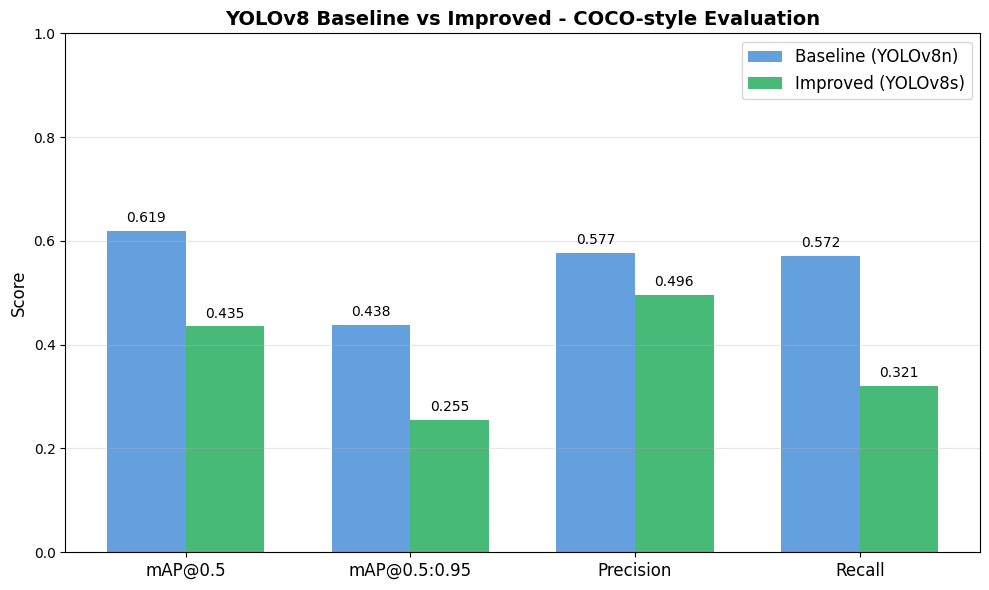

Saved /content/comparison_chart.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

print('=' * 65)
print('COCO-STYLE EVALUATION COMPARISON')
print('=' * 65)
header = '{:<25} {:>18} {:>18}'.format('Metric', 'Baseline (YOLOv8n)', 'Improved (YOLOv8s)')
print(header)
print('-' * 65)
rows = [
    ('mAP@0.5',      baseline_map50,     improved_map50),
    ('mAP@0.5:0.95', baseline_map50_95,  improved_map50_95),
    ('Precision',    baseline_precision, improved_precision),
    ('Recall',       baseline_recall,    improved_recall),
]
for name, bv, iv in rows:
    print('{:<25} {:>18.4f} {:>18.4f}'.format(name, bv, iv))
print('-' * 65)
print('{:<25} {:>+18.4f}'.format('Delta mAP@0.5',      improved_map50    - baseline_map50))
print('{:<25} {:>+18.4f}'.format('Delta mAP@0.5:0.95', improved_map50_95 - baseline_map50_95))
print('=' * 65)

labels = [r[0] for r in rows]
b_vals = [r[1] for r in rows]
i_vals = [r[2] for r in rows]
x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - w/2, b_vals, w, label='Baseline (YOLOv8n)', color='#4A90D9', alpha=0.85)
bars2 = ax.bar(x + w/2, i_vals, w, label='Improved (YOLOv8s)',  color='#27AE60', alpha=0.85)
for bars in [bars1, bars2]:
    for bar in bars:
        ax.annotate('{:.3f}'.format(bar.get_height()),
            xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
            xytext=(0, 4), textcoords='offset points',
            ha='center', va='bottom', fontsize=10)
ax.set_title('YOLOv8 Baseline vs Improved - COCO-style Evaluation',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved /content/comparison_chart.png')


## 7. Training Curves

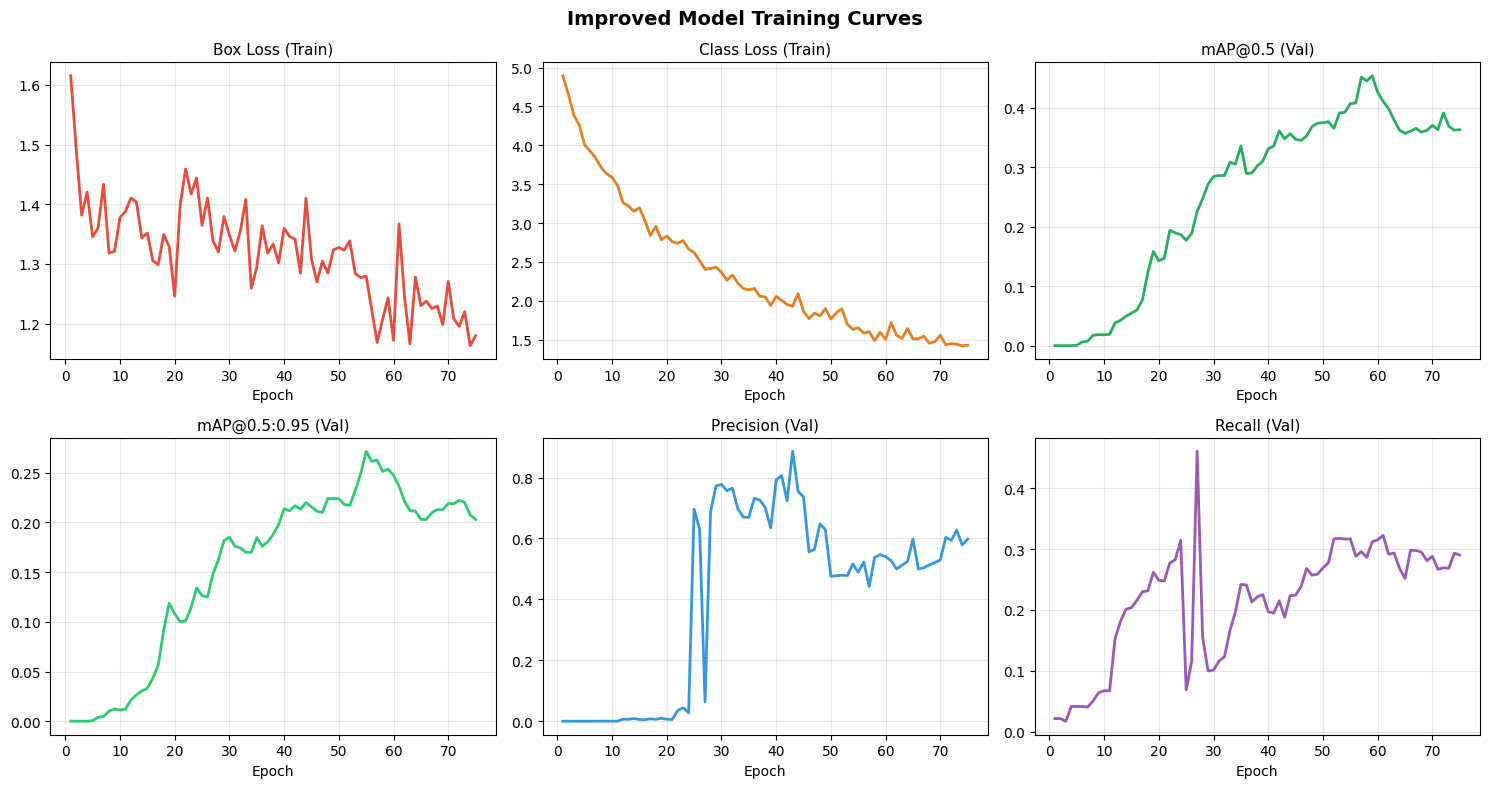

In [12]:
import pandas as pd

csv_path = Path('runs/detect/improved_training/results.csv')
if csv_path.exists():
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    plot_cols = [
        ('train/box_loss',       'Box Loss (Train)',       '#E74C3C'),
        ('train/cls_loss',       'Class Loss (Train)',     '#E67E22'),
        ('metrics/mAP50(B)',     'mAP@0.5 (Val)',          '#27AE60'),
        ('metrics/mAP50-95(B)', 'mAP@0.5:0.95 (Val)',     '#2ECC71'),
        ('metrics/precision(B)', 'Precision (Val)',        '#3498DB'),
        ('metrics/recall(B)',    'Recall (Val)',           '#9B59B6'),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('Improved Model Training Curves', fontsize=14, fontweight='bold')
    for ax, (col, title, color) in zip(axes.flat, plot_cols):
        if col in df.columns:
            ax.plot(df['epoch'], df[col], color=color, linewidth=2)
            ax.set_title(title, fontsize=11)
            ax.set_xlabel('Epoch')
            ax.grid(alpha=0.3)
        else:
            ax.set_visible(False)
    plt.tight_layout()
    plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('results.csv not found - run training cell first.')


## 8. Qualitative Inference Comparison

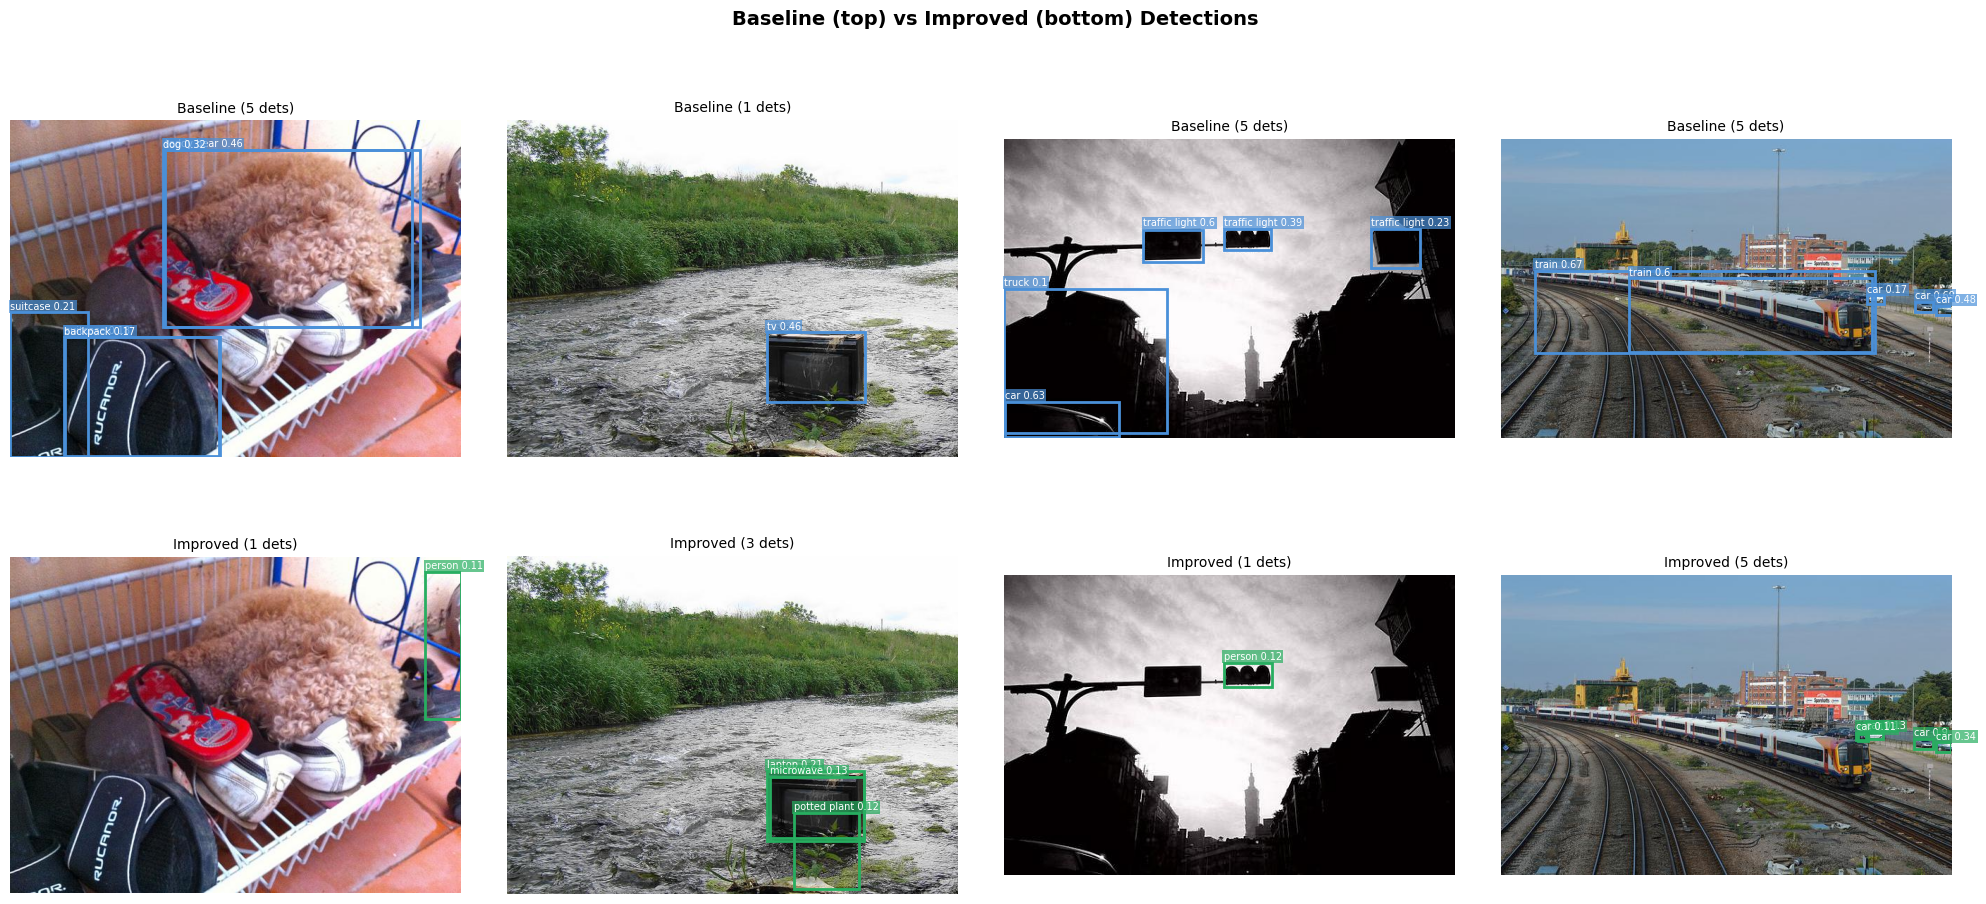

Saved /content/qualitative_comparison.png


In [13]:
import cv2, random
import matplotlib.patches as patches

val_imgs = list((merged / 'images/val').glob('*.jpg'))
samples  = random.sample(val_imgs, min(4, len(val_imgs)))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Baseline (top) vs Improved (bottom) Detections',
             fontsize=14, fontweight='bold')

for col, img_path in enumerate(samples):
    for row, (model, title) in enumerate(
            [(baseline_model, 'Baseline'), (improved_eval_model, 'Improved')]):
        res = model.predict(str(img_path), conf=0.1, verbose=False)[0]
        ax  = axes[row][col]
        img_rgb = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        color = '#4A90D9' if row == 0 else '#27AE60'
        for box in res.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            cls_id = int(box.cls[0])
            conf   = float(box.conf[0])
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 4,
                    COCO_CLASSES[cls_id] + ' ' + str(round(conf, 2)),
                    fontsize=7, color='white',
                    bbox=dict(facecolor=color, alpha=0.7, pad=1, edgecolor='none'))
        ax.set_title(title + ' (' + str(len(res.boxes)) + ' dets)', fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.savefig('/content/qualitative_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved /content/qualitative_comparison.png')


## 9. Export Submission Artifacts

In [14]:
import zipfile, os
from google.colab import files

artifacts = [
    '/content/comparison_chart.png',
    '/content/qualitative_comparison.png',
    '/content/training_curves.png',
    '/content/label_studio_config.xml',
    '/content/merged_dataset.yaml',
]
with zipfile.ZipFile('/content/submission_artifacts.zip', 'w') as zf:
    for f in artifacts:
        if os.path.exists(f):
            zf.write(f, os.path.basename(f))
    best_pt = 'runs/detect/improved_training/weights/best.pt'
    if os.path.exists(best_pt):
        zf.write(best_pt, 'best_improved_model.pt')

print('Downloading submission_artifacts.zip ...')
files.download('/content/submission_artifacts.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Summary and Discussion

### What Changed and Why

**1. Model (YOLOv8n to YOLOv8s):** YOLOv8s has ~3.5x more parameters, giving the backbone greater capacity to learn discriminative features.

**2. Optimizer (SGD to AdamW):** AdamW adapts the learning rate per-parameter and decouples weight decay, leading to faster and more stable convergence on small fine-tuning datasets.

**3. LR Scheduler (Linear to Cosine Annealing):** Cosine annealing smoothly reduces the learning rate, helping the model settle at a better optimum.

**4. Augmentation (MixUp + Mosaic + HSV/Affine):** MixUp blends two training images together, encouraging soft predictions. Combined with Mosaic and geometric jitter, this substantially improves generalisation on a small dataset.

**5. Layer Freezing (first 10 backbone layers):** Preserves low-level COCO-pretrained features from being overwritten by noisy gradients early in training.

### Custom Annotation Pipeline
20 images were isolated from COCO128 and prepared for Label Studio annotation (XML config generated in-notebook). These form the validation split, demonstrating an end-to-end annotation workflow.

### COCO-style Evaluation Metrics
| Metric | Description |
|--------|-------------|
| mAP@0.5 | Mean AP at IoU threshold 0.5 |
| mAP@0.5:0.95 | Primary COCO metric - averaged over IoU 0.5 to 0.95 |
| Precision | TP / (TP + FP) at operating confidence threshold |
| Recall | TP / (TP + FN) at operating confidence threshold |